# Chest X-Ray Pneumonia Classification - Research Submission Notebook

This notebook is the final execution artifact for the current repository state. It is inspired by `notebooks/original_old_notebook.ipynb`, but it uses the maintained package, YAML configurations, saved experiment artifacts, and latest smooth-training results instead of duplicating one-off notebook training code.

**Task:** classify pediatric chest X-rays into three classes: `Normal`, `Bacterial pneumonia`, and `Viral pneumonia`.

**Repository workflow used here:**

- dataset validation: `python3 prepare.py --no-download`
- config-driven training: `PYTHONPATH=src python3 experiments/run_experiment.py --config <config.yaml>`
- saved run artifacts: `outputs/runs/<experiment_name>/metrics.json`, `resolved_config.json`, checkpoint, training curves, and confusion matrices

The long training jobs have already been executed and saved. This notebook re-executes the preparation and reporting pipeline, audits the produced artifacts, and renders the plots/log outputs needed for GitHub review without overwriting trained checkpoints.


In [1]:
from __future__ import annotations

import json
import os
import platform
import random
import subprocess
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "chest_xray"
CONFIG_DIR = PROJECT_ROOT / "configs"
RUNS_DIR = PROJECT_ROOT / "outputs" / "runs"
PREPARE_REPORT = PROJECT_ROOT / "data" / "processed" / "prepare_report.json"
CLASS_NAMES = ["Normal", "Bacterial", "Viral"]

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
print(f"Dataset root exists: {DATA_ROOT.exists()}")
print(f"Run directory exists: {RUNS_DIR.exists()}")


Project root: /home/aya555levi/chest_xray_classification
Python: 3.12.3
Platform: Linux-6.17.0-1010-gcp-x86_64-with-glibc2.39
PyTorch: 2.9.1+cu129
CUDA available: True
CUDA device: NVIDIA L4
Dataset root exists: True
Run directory exists: True


## 1. Dataset Preparation and Validation

The original notebook downloaded the Kaggle data inside Colab. The current project keeps that concern in `prepare.py`, which validates the local Kaggle folder structure and writes a stable JSON preparation report. The label mapping remains:

| Folder / filename rule | Label |
|---|---|
| `NORMAL/` | Normal |
| `PNEUMONIA/*bacteria*` | Bacterial |
| `PNEUMONIA/*virus*` | Viral |

The maintained training code pools Kaggle `train` and tiny Kaggle `val`, then creates a stratified internal validation split. Kaggle `test` is held out as the final test set.


In [2]:
result = subprocess.run(
    [sys.executable, "prepare.py", "--no-download"],
    cwd=PROJECT_ROOT,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    check=True,
)
print(result.stdout)

prepare_report = json.loads(PREPARE_REPORT.read_text())
rows = []
for split, details in prepare_report["splits"].items():
    row = {"split": split, "num_images": details["num_images"]}
    row.update({name: details["label_distribution"].get(name, 0) for name in CLASS_NAMES})
    rows.append(row)
prepare_df = pd.DataFrame(rows).set_index("split").loc[["train", "val", "test"]]
print(prepare_df.to_string())


✓ Prepared dataset report at: /home/aya555levi/chest_xray_classification/data/processed/prepare_report.json
  train: 5216 images | {'Normal': 1341, 'Bacterial': 2530, 'Viral': 1345}
  val: 16 images | {'Normal': 8, 'Bacterial': 8}
  test: 624 images | {'Normal': 234, 'Bacterial': 242, 'Viral': 148}

       num_images  Normal  Bacterial  Viral
split                                      
train        5216    1341       2530   1345
val            16       8          8      0
test          624     234        242    148


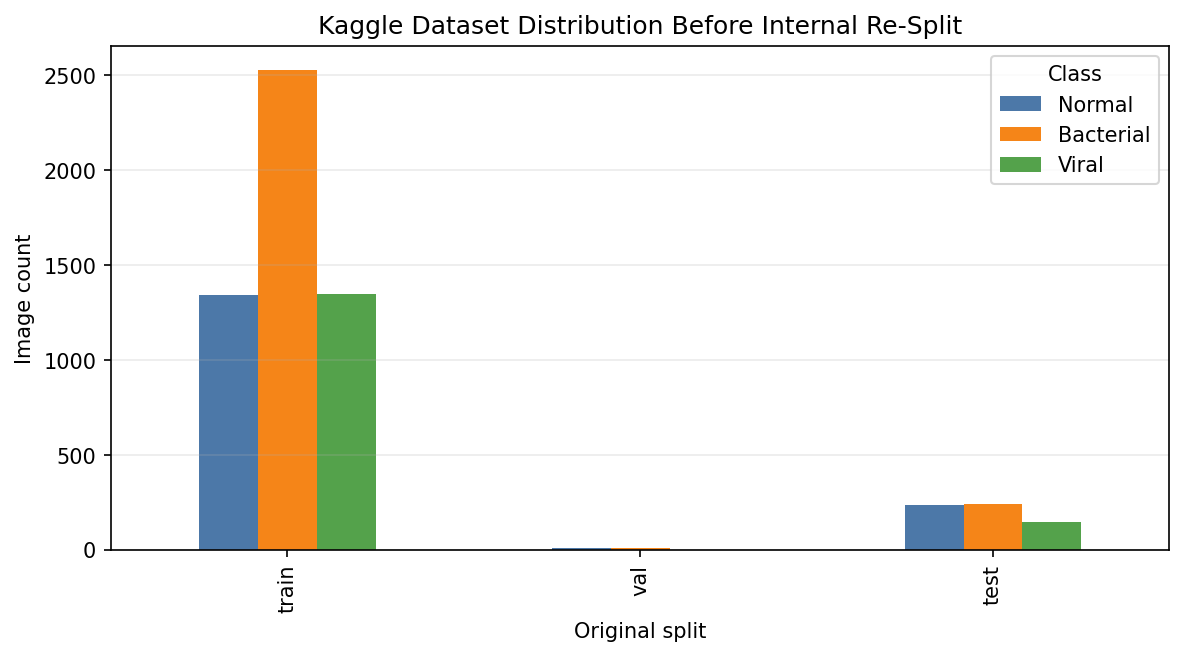

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
prepare_df[CLASS_NAMES].plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518", "#54a24b"])
ax.set_title("Kaggle Dataset Distribution Before Internal Re-Split")
ax.set_xlabel("Original split")
ax.set_ylabel("Image count")
ax.legend(title="Class")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()


## 2. Representative Images

The sample below is rendered from the local dataset after validation. Images are shown only for visual sanity checking; the training pipeline resizes and normalizes them through `src/chest_xray_project/transforms.py`.


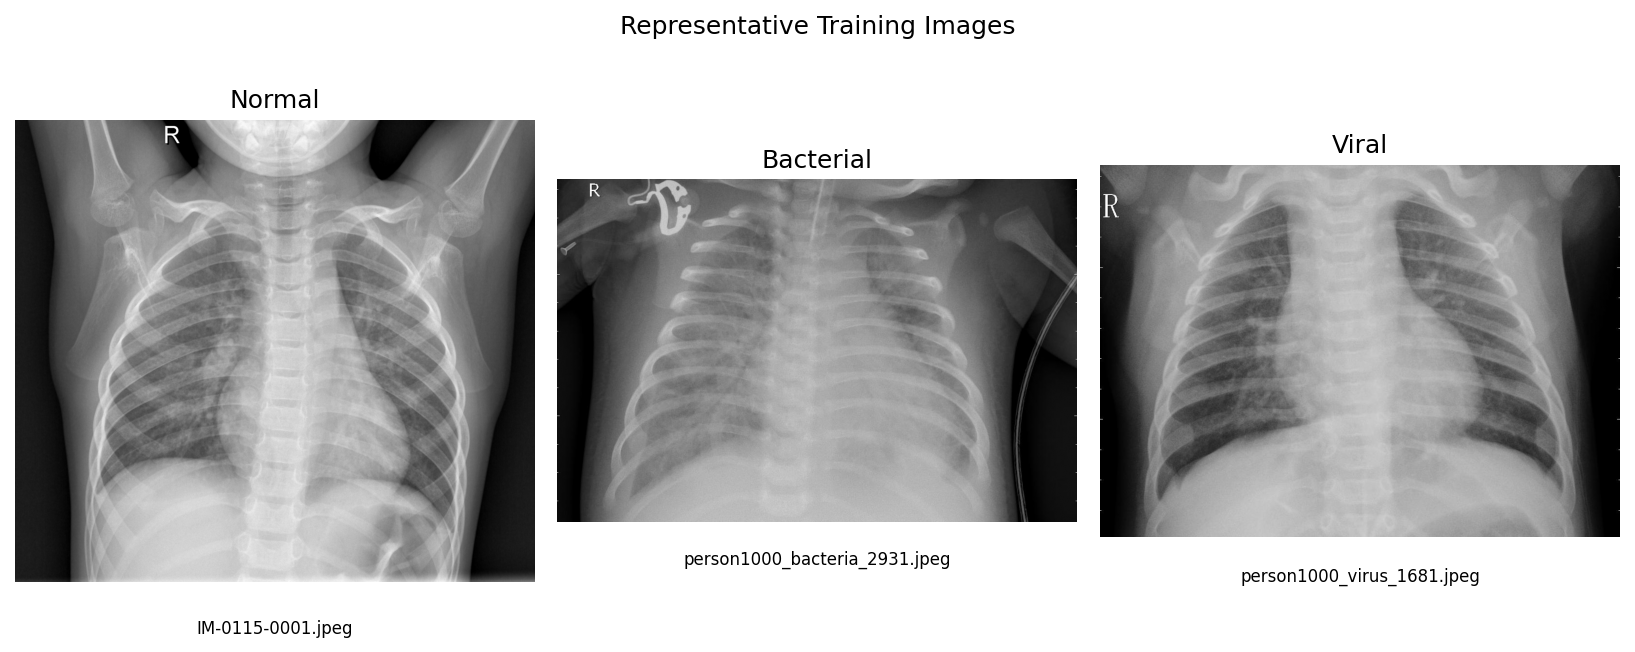

In [4]:
def first_image_for(label_name: str) -> Path:
    if label_name == "Normal":
        candidates = sorted((DATA_ROOT / "train" / "NORMAL").glob("*.jpeg"))
    elif label_name == "Bacterial":
        candidates = sorted(p for p in (DATA_ROOT / "train" / "PNEUMONIA").glob("*.jpeg") if "bacteria" in p.name.lower())
    else:
        candidates = sorted(p for p in (DATA_ROOT / "train" / "PNEUMONIA").glob("*.jpeg") if "virus" in p.name.lower())
    if not candidates:
        raise FileNotFoundError(label_name)
    return candidates[0]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, class_name in zip(axes, CLASS_NAMES):
    path = first_image_for(class_name)
    image = Image.open(path).convert("L")
    ax.imshow(image, cmap="gray")
    ax.set_title(class_name)
    ax.axis("off")
    ax.text(0.5, -0.08, path.name[:34], transform=ax.transAxes, ha="center", va="top", fontsize=8)
fig.suptitle("Representative Training Images", y=1.02)
fig.tight_layout()
plt.show()


## 3. Maintained Source Pipeline

The current project replaces notebook-local training definitions with a reusable package:

| Concern | Current module |
|---|---|
| Config loading and defaults | `src/chest_xray_project/config.py` |
| Label inference and stratified split | `src/chest_xray_project/data.py` |
| Dataset, dataloaders, sampler, class weights | `src/chest_xray_project/dataloaders.py` |
| Augmentation and normalization | `src/chest_xray_project/transforms.py` |
| CNN, EfficientNet, patch-LSTM models | `src/chest_xray_project/models.py` |
| Train/evaluate loop and metrics | `src/chest_xray_project/training.py` |
| Saved figures | `src/chest_xray_project/visualization.py` |

This notebook inspects the resolved configs saved with each run, which is the most reliable record of what was executed.


In [5]:
config_rows = []
for metrics_path in sorted(RUNS_DIR.glob("*/metrics.json")):
    run_dir = metrics_path.parent
    resolved = json.loads((run_dir / "resolved_config.json").read_text())
    model = resolved["model"]
    data = resolved["data"]
    training = resolved["training"]
    optimizer = resolved["optimizer"]
    config_rows.append({
        "run": run_dir.name,
        "model": model["name"],
        "freeze_backbone": model.get("freeze_backbone"),
        "finetune_blocks": str(model.get("finetune_blocks")),
        "patch_size": model.get("patch_size"),
        "augmentation": data.get("augmentation_profile", "standard"),
        "weighted_sampler": data.get("use_weighted_sampler", False),
        "class_weights": data.get("use_class_weights", True),
        "lr": optimizer["lr"],
        "epochs_limit": training["epochs"],
        "patience": training["patience"],
        "scheduler": training.get("scheduler", "none"),
    })
config_df = pd.DataFrame(config_rows).sort_values("run")
print(config_df.to_string(index=False))


                             run        model  freeze_backbone finetune_blocks  patch_size augmentation  weighted_sampler  class_weights       lr  epochs_limit  patience         scheduler
                    a_custom_cnn          cnn            False              []          16     standard             False           True 0.000500            40        10              none
             a_custom_cnn_smooth          cnn            False              []          16       gentle              True          False 0.000200            40        10 reduce_on_plateau
  a_custom_cnn_smooth_no_sampler          cnn            False              []          16       gentle             False           True 0.000200            40        10 reduce_on_plateau
          b1_frozen_efficientnet efficientnet             True              []          16     standard             False           True 0.000500            40        10              none
   b1_frozen_efficientnet_smooth efficientnet             Tr

## 4. Experiment Matrix and Results

The completed experiment set covers:

- **Stage A:** custom CNN baseline and smooth variants
- **Stage B1:** frozen EfficientNet-B0 transfer-learning variants
- **Stage B2:** EfficientNet-B0 with final blocks unfrozen
- **Stage C:** patch-LSTM proxy using non-overlapping image patches

Metrics are loaded directly from `outputs/runs/*/metrics.json`.


In [6]:
def load_run_summary(run_dir: Path) -> dict:
    metrics = json.loads((run_dir / "metrics.json").read_text())
    resolved = json.loads((run_dir / "resolved_config.json").read_text())
    history = metrics["history"]
    return {
        "run": run_dir.name,
        "model": metrics["model"]["name"],
        "epochs_ran": len(history["train_loss"]),
        "train_time_min": metrics["train_time_seconds"] / 60,
        "total_params": metrics["model"]["total_parameters"],
        "trainable_params": metrics["model"]["trainable_parameters"],
        "val_accuracy": metrics["validation"]["accuracy"],
        "val_macro_f1": metrics["validation"]["macro_f1"],
        "test_accuracy": metrics["test"]["accuracy"],
        "test_macro_f1": metrics["test"]["macro_f1"],
        "test_loss": metrics["test"]["loss"],
        "augmentation": resolved["data"].get("augmentation_profile", "standard"),
        "weighted_sampler": resolved["data"].get("use_weighted_sampler", False),
        "class_weights": resolved["data"].get("use_class_weights", True),
    }

summary_df = pd.DataFrame(load_run_summary(p.parent) for p in sorted(RUNS_DIR.glob("*/metrics.json")))
summary_df = summary_df.sort_values(["test_macro_f1", "test_accuracy"], ascending=False).reset_index(drop=True)
show_df = summary_df.copy()
for col in ["train_time_min", "val_accuracy", "val_macro_f1", "test_accuracy", "test_macro_f1", "test_loss"]:
    show_df[col] = show_df[col].map(lambda x: f"{x:.4f}" if col != "train_time_min" else f"{x:.1f}")
print(show_df.to_string(index=False))

best = summary_df.iloc[0]
print("\nBest by test macro-F1:")
print(f"{best['run']} | test_macro_f1={best['test_macro_f1']:.4f}, test_accuracy={best['test_accuracy']:.4f}")


                             run        model  epochs_ran train_time_min  total_params  trainable_params val_accuracy val_macro_f1 test_accuracy test_macro_f1 test_loss augmentation  weighted_sampler  class_weights
       b2_finetuned_efficientnet efficientnet          25           20.0       4730751           1852595       0.7345       0.7271        0.8349        0.8269    0.5436     standard             False           True
b2_finetuned_efficientnet_smooth efficientnet          25           20.6       4730751           1852595       0.7431       0.7375        0.8189        0.8118    0.5834       gentle              True          False
   b1_frozen_efficientnet_smooth efficientnet          16           13.2       4730751            723203       0.7603       0.7601        0.7917        0.7819    0.6445       gentle              True          False
          b1_frozen_efficientnet efficientnet          34           27.3       4730751            723203       0.7412       0.7394        0.

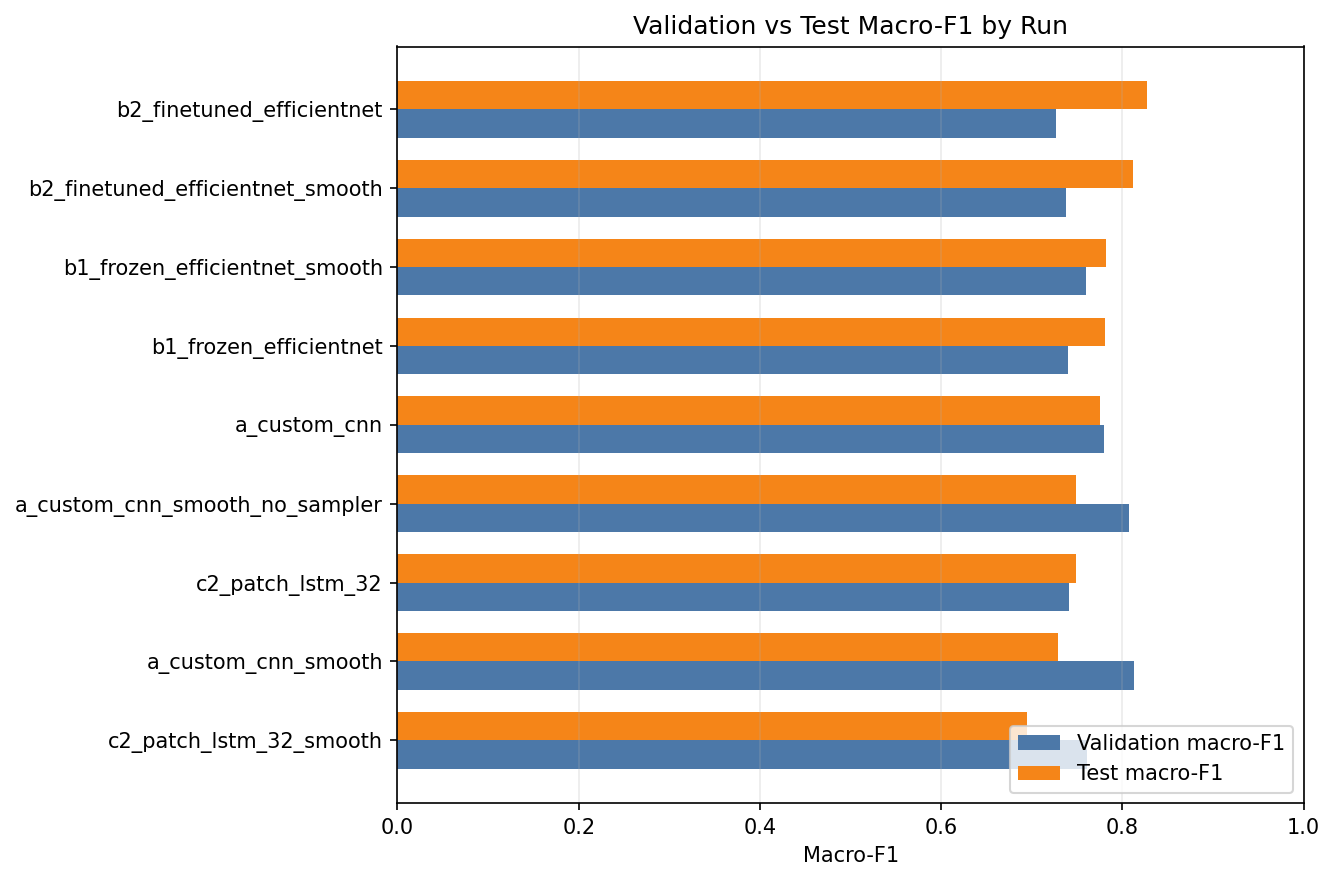

In [7]:
plot_df = summary_df.sort_values("test_macro_f1")
y = np.arange(len(plot_df))
height = 0.36
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(y - height/2, plot_df["val_macro_f1"], height, label="Validation macro-F1", color="#4c78a8")
ax.barh(y + height/2, plot_df["test_macro_f1"], height, label="Test macro-F1", color="#f58518")
ax.set_yticks(y)
ax.set_yticklabels(plot_df["run"])
ax.set_xlabel("Macro-F1")
ax.set_xlim(0.0, 1.0)
ax.set_title("Validation vs Test Macro-F1 by Run")
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()


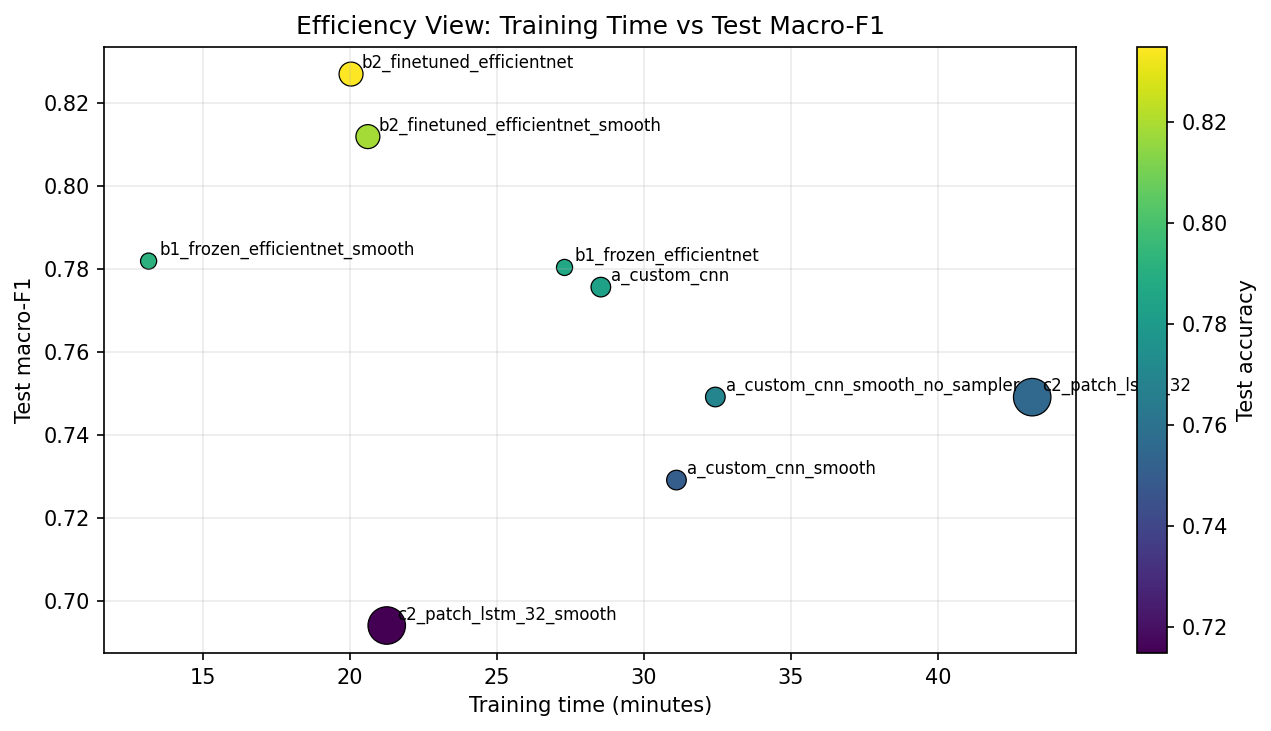

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    summary_df["train_time_min"],
    summary_df["test_macro_f1"],
    s=np.clip(summary_df["trainable_params"] / 14000, 60, 360),
    c=summary_df["test_accuracy"],
    cmap="viridis",
    edgecolor="black",
    linewidth=0.6,
)
for _, row in summary_df.iterrows():
    ax.annotate(row["run"], (row["train_time_min"], row["test_macro_f1"]), xytext=(5, 3), textcoords="offset points", fontsize=8)
ax.set_title("Efficiency View: Training Time vs Test Macro-F1")
ax.set_xlabel("Training time (minutes)")
ax.set_ylabel("Test macro-F1")
ax.grid(alpha=0.25)
cb = fig.colorbar(scatter, ax=ax)
cb.set_label("Test accuracy")
fig.tight_layout()
plt.show()


## 5. Training Curves

These curves are reconstructed from the saved per-epoch histories in `metrics.json`. The training loop uses validation loss for checkpoint selection and early stopping.


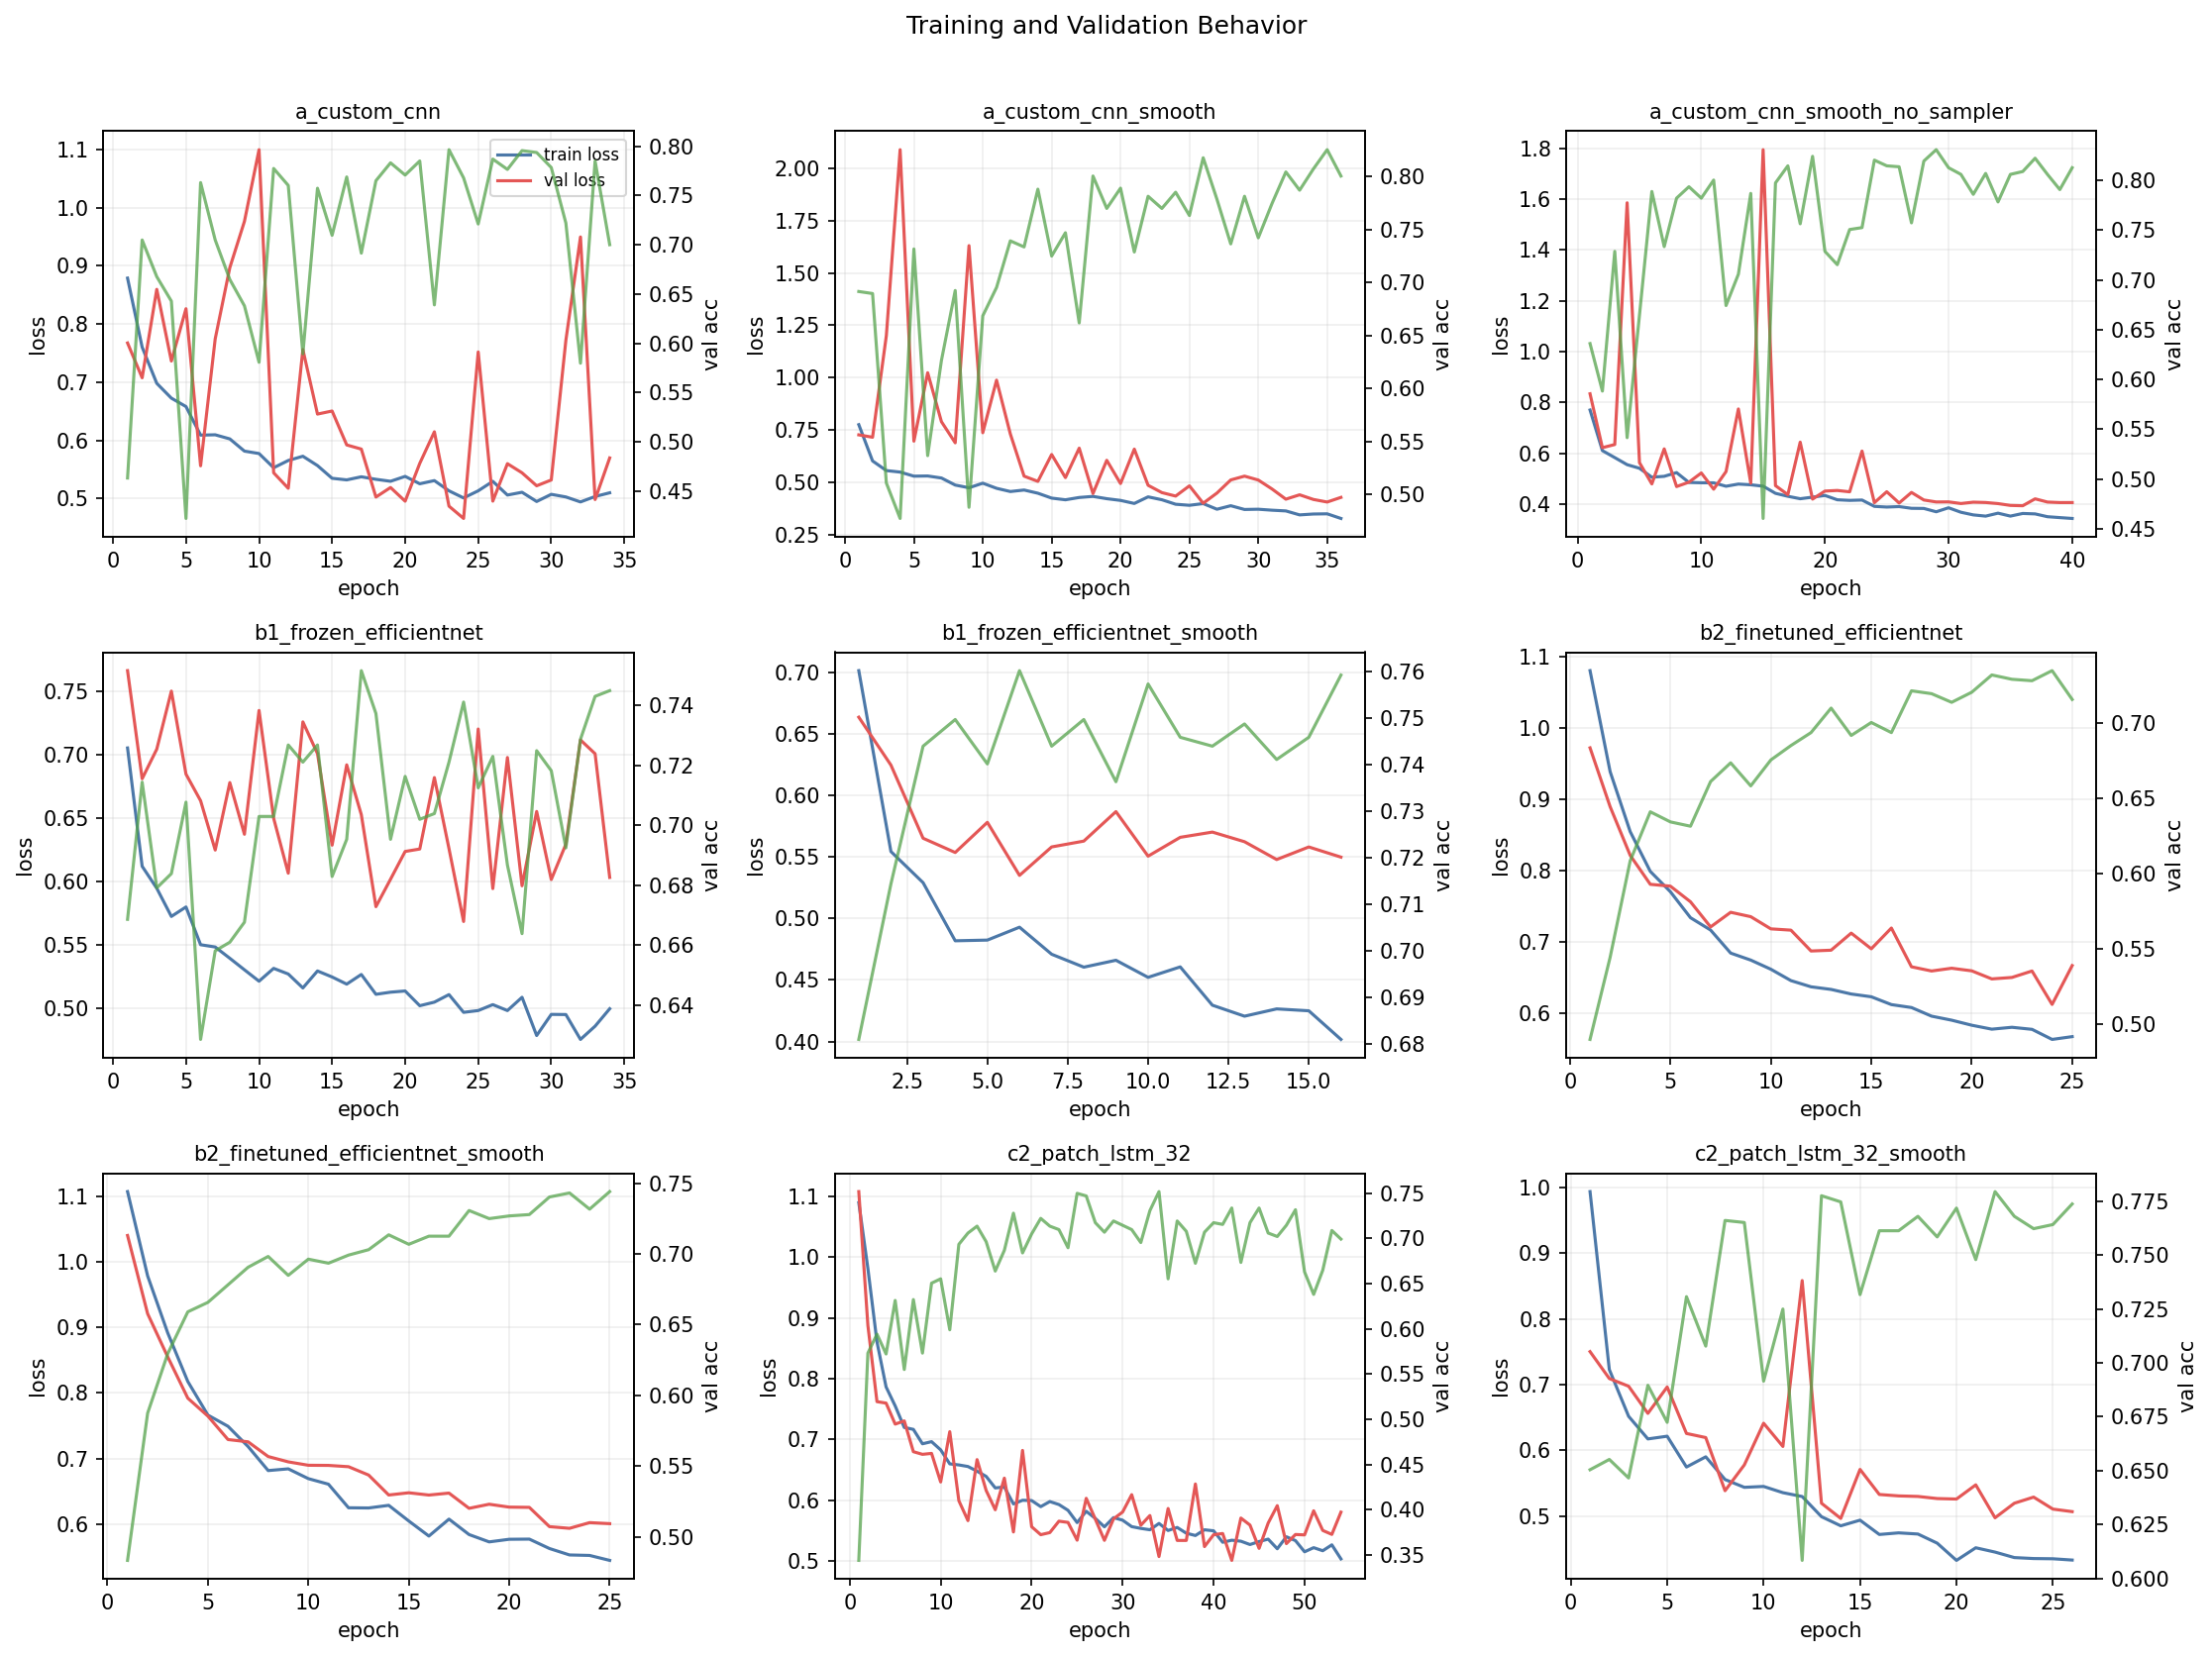

In [9]:
ordered_runs = [
    "a_custom_cnn", "a_custom_cnn_smooth", "a_custom_cnn_smooth_no_sampler",
    "b1_frozen_efficientnet", "b1_frozen_efficientnet_smooth",
    "b2_finetuned_efficientnet", "b2_finetuned_efficientnet_smooth",
    "c2_patch_lstm_32", "c2_patch_lstm_32_smooth",
]
fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=False)
for ax, run in zip(axes.ravel(), ordered_runs):
    metrics = json.loads((RUNS_DIR / run / "metrics.json").read_text())
    history = metrics["history"]
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], label="train loss", color="#4c78a8")
    ax.plot(epochs, history["val_loss"], label="val loss", color="#e45756")
    twin = ax.twinx()
    twin.plot(epochs, history["val_acc"], label="val acc", color="#54a24b", alpha=0.75)
    ax.set_title(run, fontsize=10)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    twin.set_ylabel("val acc")
    ax.grid(alpha=0.2)
axes[0, 0].legend(loc="upper right", fontsize=8)
fig.suptitle("Training and Validation Behavior", y=1.01)
fig.tight_layout()
plt.show()


## 6. Confusion Matrices

Confusion matrices are loaded from the same numerical values used to create the saved PNG artifacts. Rows are true labels and columns are predictions.


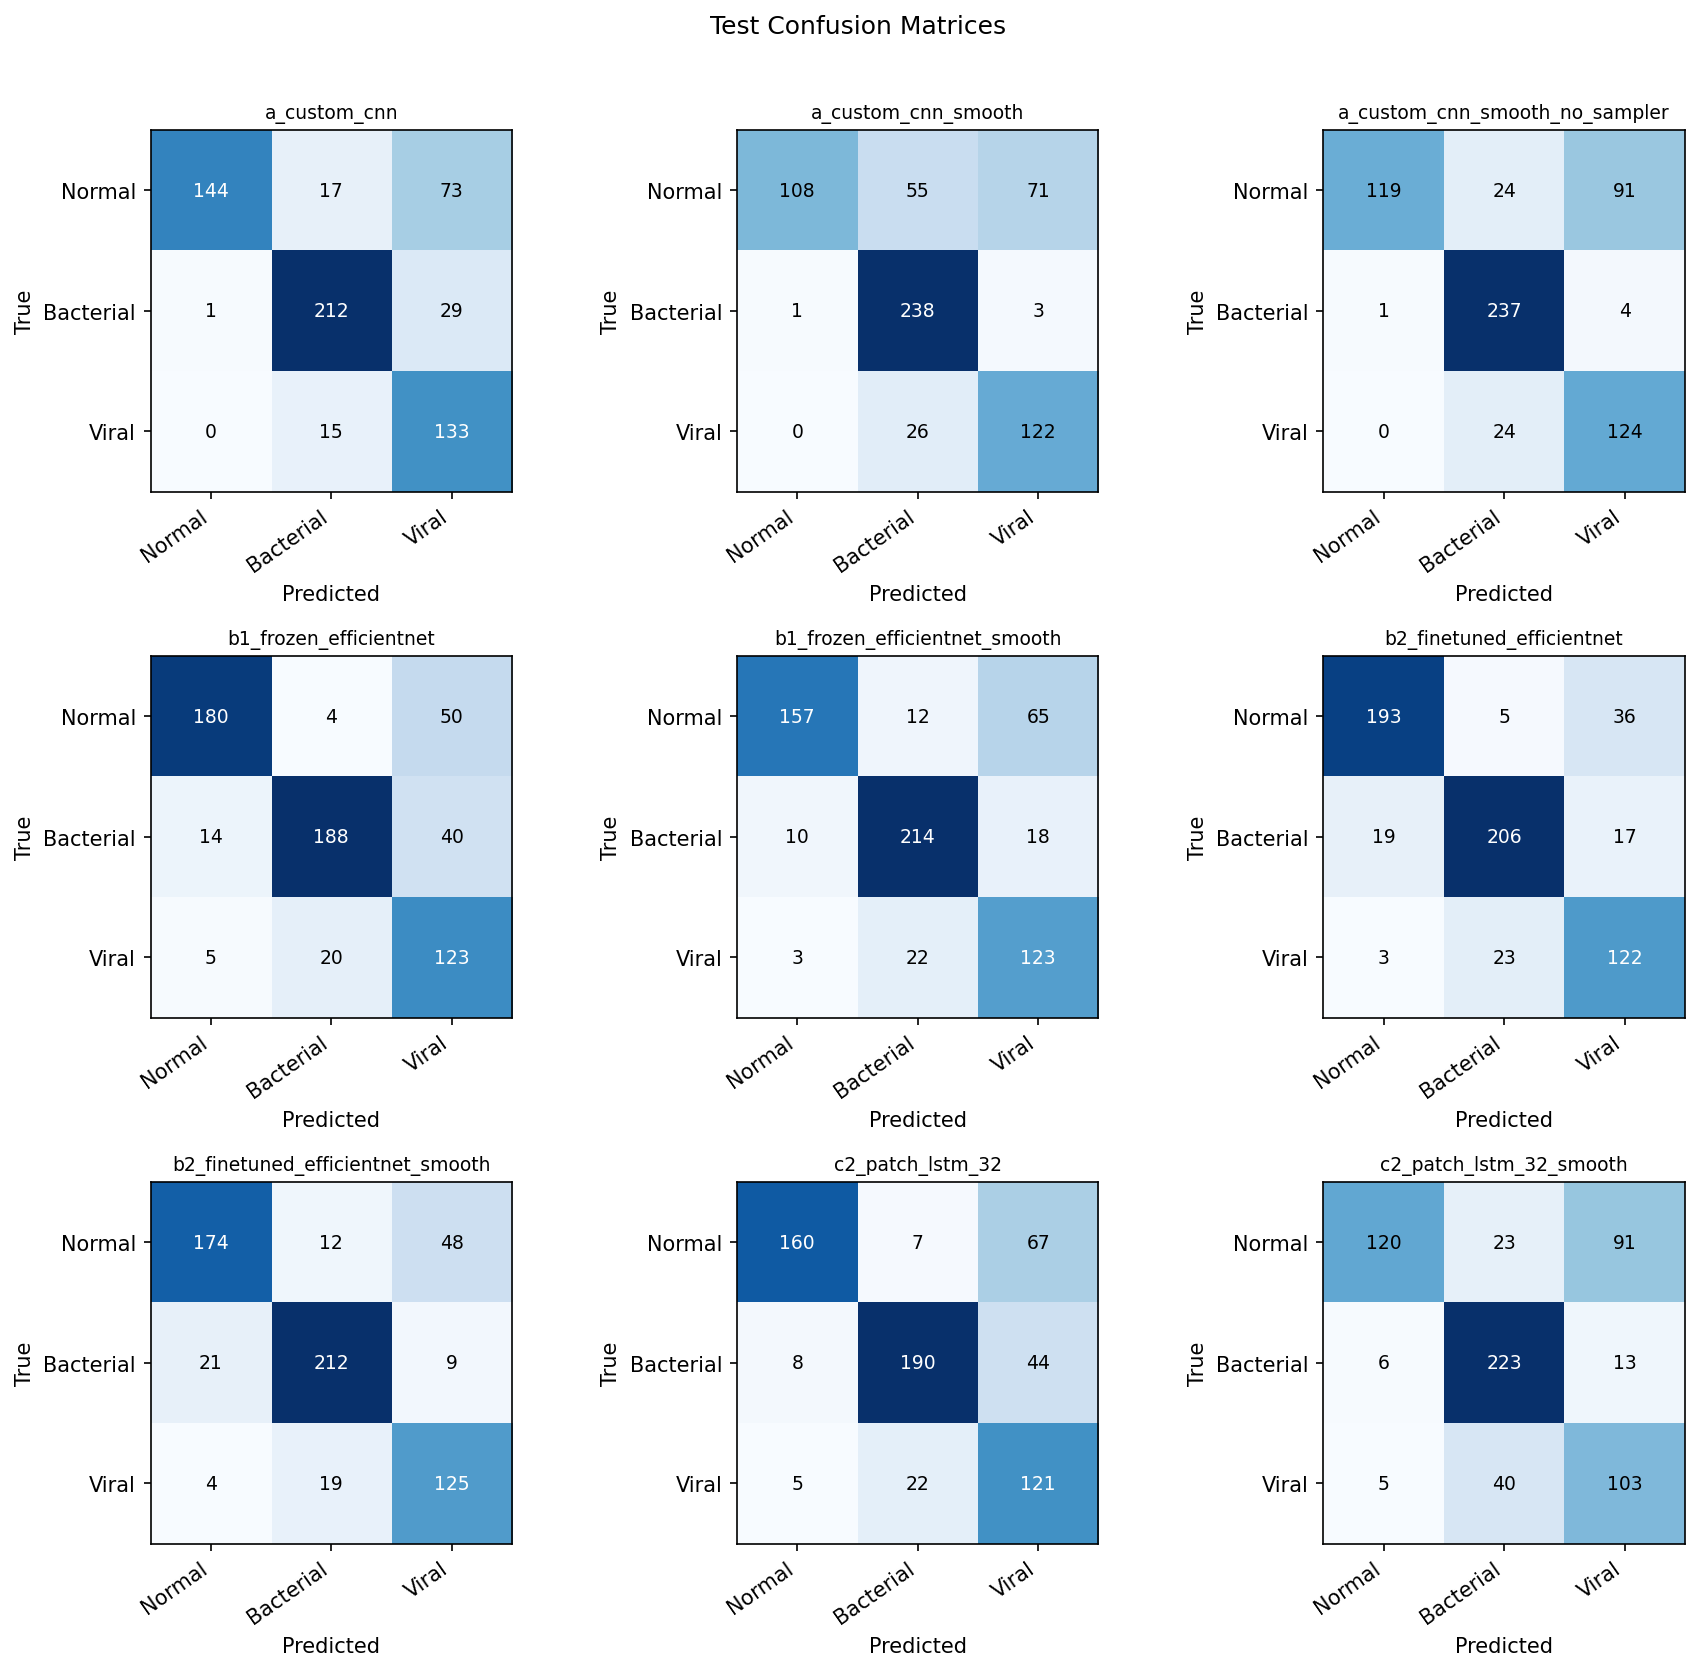

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(12, 11))
for ax, run in zip(axes.ravel(), ordered_runs):
    metrics = json.loads((RUNS_DIR / run / "metrics.json").read_text())
    cm = np.array(metrics["test"]["confusion_matrix"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(run, fontsize=9)
    ax.set_xticks(range(3), CLASS_NAMES, rotation=35, ha="right")
    ax.set_yticks(range(3), CLASS_NAMES)
    for i in range(3):
        for j in range(3):
            color = "white" if cm[i, j] > cm.max() * 0.55 else "black"
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", color=color, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
fig.suptitle("Test Confusion Matrices", y=1.01)
fig.tight_layout()
plt.show()


## 7. Class-Level Performance for the Best Run

The strongest held-out result is selected by test macro-F1, which is stricter than accuracy under class imbalance. This cell expands the per-class report saved by the training pipeline.


In [11]:
best_run = summary_df.iloc[0]["run"]
best_metrics = json.loads((RUNS_DIR / best_run / "metrics.json").read_text())
report = best_metrics["test"]["classification_report"]
class_rows = []
for class_name in CLASS_NAMES:
    values = report[class_name]
    class_rows.append({
        "class": class_name,
        "precision": values["precision"],
        "recall": values["recall"],
        "f1-score": values["f1-score"],
        "support": int(values["support"]),
    })
class_df = pd.DataFrame(class_rows)
print(f"Best run: {best_run}")
print(class_df.to_string(index=False, formatters={
    "precision": "{:.4f}".format,
    "recall": "{:.4f}".format,
    "f1-score": "{:.4f}".format,
}))


Best run: b2_finetuned_efficientnet
    class precision recall f1-score  support
   Normal    0.8977 0.8248   0.8597      234
Bacterial    0.8803 0.8512   0.8655      242
    Viral    0.6971 0.8243   0.7554      148


## 8. Training Commands and Logs

The exact commands below reproduce the completed run set from the current source tree. They are printed, not launched, because re-running them would take several hours and overwrite or mutate trained artifacts.


In [12]:
commands = [
    "PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_cnn.yaml",
    "PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_cnn_smooth.yaml",
    "PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_cnn_smooth_no_sampler.yaml",
    "PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_effnet_frozen.yaml",
    "PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_effnet_frozen_smooth.yaml",
    "PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_effnet_finetune.yaml",
    "PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_effnet_finetune_smooth.yaml",
    "PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_lstm32.yaml",
    "PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_lstm32_smooth.yaml",
]
print("Reproduction commands:")
for i, command in enumerate(commands, 1):
    print(f"{i}. {command}")

print("\nArtifact completeness audit:")
required = ["metrics.json", "resolved_config.json", "best_model.pt", "training_curves.png", "validation_confusion_matrix.png", "test_confusion_matrix.png"]
for run in ordered_runs:
    missing = [name for name in required if not (RUNS_DIR / run / name).exists()]
    status = "OK" if not missing else "MISSING " + ", ".join(missing)
    print(f"{run}: {status}")


Reproduction commands:
1. PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_cnn.yaml
2. PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_cnn_smooth.yaml
3. PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_cnn_smooth_no_sampler.yaml
4. PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_effnet_frozen.yaml
5. PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_effnet_frozen_smooth.yaml
6. PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_effnet_finetune.yaml
7. PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_effnet_finetune_smooth.yaml
8. PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_lstm32.yaml
9. PYTHONPATH=src python3 experiments/run_experiment.py --config configs/model_lstm32_smooth.yaml

Artifact completeness audit:
a_custom_cnn: OK
a_custom_cnn_smooth: OK
a_custom_cnn_smoot

In [13]:
log_candidates = [
    PROJECT_ROOT / "outputs" / "pytorch_logs_by_model" / "a_custom_cnn.txt",
    PROJECT_ROOT / "outputs" / "pytorch_logs_by_model" / "b1_frozen_efficientnet.txt",
    PROJECT_ROOT / "outputs" / "pytorch_logs_by_model" / "b2_finetuned_efficientnet.txt",
    PROJECT_ROOT / "outputs" / "pytorch_logs_by_model" / "c2_patch_lstm_32.txt",
    PROJECT_ROOT / "run.log",
]
for path in log_candidates:
    if not path.exists():
        continue
    lines = path.read_text(errors="replace").splitlines()
    print("=" * 90)
    print(path.relative_to(PROJECT_ROOT))
    print("\n".join(lines[-18:]))


outputs/pytorch_logs_by_model/a_custom_cnn.txt
[a_custom_cnn] Epoch 26/40 | Train 0.5293/0.7450 | Val 0.4953/0.7870 | Patience 2/10
[a_custom_cnn] Epoch 27/40 | Train 0.5057/0.7568 | Val 0.5597/0.7765 | Patience 3/10
[a_custom_cnn] Epoch 28/40 | Train 0.5105/0.7520 | Val 0.5440/0.7956 | Patience 4/10
[a_custom_cnn] Epoch 29/40 | Train 0.4946/0.7665 | Val 0.5217/0.7937 | Patience 5/10
[a_custom_cnn] Epoch 30/40 | Train 0.5070/0.7572 | Val 0.5316/0.7784 | Patience 6/10
[a_custom_cnn] Epoch 31/40 | Train 0.5024/0.7584 | Val 0.7719/0.7221 | Patience 7/10
[a_custom_cnn] Epoch 32/40 | Train 0.4939/0.7608 | Val 0.9498/0.5798 | Patience 8/10
[a_custom_cnn] Epoch 33/40 | Train 0.5032/0.7618 | Val 0.4980/0.7851 | Patience 9/10
[a_custom_cnn] Epoch 34/40 | Train 0.5096/0.7577 | Val 0.5696/0.7001 | Patience 10/10
[a_custom_cnn] Epoch 26/40 | Train 0.5293/0.7450 | Val 0.4953/0.7870 | Patience 2/10
[a_custom_cnn] Epoch 27/40 | Train 0.5057/0.7568 | Val 0.5597/0.7765 | Patience 3/10
[a_custom_cnn] Ep

## 9. Research Insights

1. **Best held-out result:** `b2_finetuned_efficientnet` has the best test macro-F1 and test accuracy in the saved run set. Fine-tuning EfficientNet blocks 7 and 8 gave the strongest generalization on Kaggle test.
2. **Best validation accuracy is not the same as best test result:** smooth CNN variants improved validation behavior, but the best validation run did not dominate held-out test macro-F1. This reinforces using the held-out Kaggle test split only for final comparison.
3. **Smooth training helped stability, not always final score:** lower learning rate, gentler augmentation, gradient clipping, and `ReduceLROnPlateau` made some curves steadier, especially for frozen EfficientNet, but the original fine-tuned EfficientNet remained strongest on test.
4. **Patch sequence modeling is viable but weaker here:** the 32-patch LSTM reached a competitive but lower test macro-F1 than EfficientNet. It is a useful proxy for patch-based reasoning, but the repository does not contain a full ViT implementation.
5. **Class imbalance is central:** Normal, bacterial, and viral examples are unevenly distributed. The pipeline explicitly evaluates macro-F1, supports class weights or weighted sampling, and reports confusion matrices to avoid relying on accuracy alone.

## 10. Final Conclusion

The latest maintained pipeline successfully converts the original notebook into a reproducible research workflow. The recommended model from the current completed artifacts is `b2_finetuned_efficientnet`, selected by held-out test macro-F1. The project now has clear preparation, configuration, training, evaluation, and reporting artifacts suitable for submission review on GitHub.
